## Upload File in Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752 (1).xlsx to phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752 (1).xlsx


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
file_path = list(uploaded.keys())[0]

xls = pd.ExcelFile(file_path)

state = pd.read_excel(xls, 'State_Txn and Users')
txn = pd.read_excel(xls, 'State_TxnSplit')
device = pd.read_excel(xls, 'State_DeviceData')
district = pd.read_excel(xls, 'District_Txn and Users')
demo = pd.read_excel(xls, 'District Demographics')

print("Data Loaded Successfully ✅")

Data Loaded Successfully ✅


## Data Cleaning

In [4]:
# Fill missing values
for df in [state, txn, device, district]:
    df.fillna(0, inplace=True)

# Remove duplicates
state.drop_duplicates(inplace=True)

# Fix datatypes
state['Year'] = state['Year'].astype(int)
district['Year'] = district['Year'].astype(int)

print("Data Cleaned ✅")

Data Cleaned ✅


## State-wise Transaction Analysis

,Amount (INR)
State,
Telangana,4.574246e+12
Karnataka,4.361396e+12
Maharashtra,4.290995e+12
Andhra Pradesh,3.187847e+12
Rajasthan,2.625584e+12
Uttar Pradesh,2.399757e+12
Madhya Pradesh,1.915101e+12
Delhi,1.649942e+12
Bihar,1.639579e+12


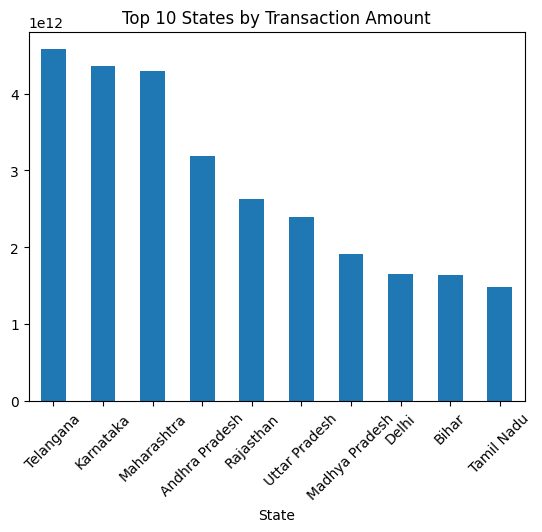

In [6]:
state_txn = state.groupby('State')['Amount (INR)'].sum().sort_values(ascending=False)

display(state_txn.head(10))

state_txn.head(10).plot(kind='bar')
plt.title("Top 10 States by Transaction Amount")
plt.xticks(rotation=45)
plt.show()

## Year-wise Trend

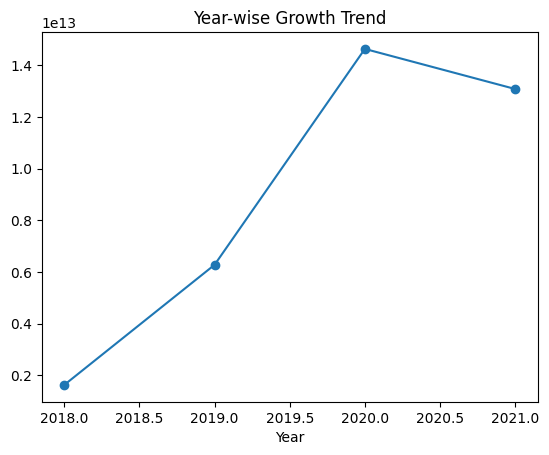

In [8]:
year_trend = state.groupby('Year')['Amount (INR)'].sum()

year_trend.plot(marker='o')
plt.title("Year-wise Growth Trend")
plt.show()

## Top & Bottom States

In [9]:
print("Top 5 States:\n", state_txn.head())
print("\nBottom 5 States:\n", state_txn.tail())

Top 5 States:
 State
Telangana         4.574246e+12
Karnataka         4.361396e+12
Maharashtra       4.290995e+12
Andhra Pradesh    3.187847e+12
Rajasthan         2.625584e+12
Name: Amount (INR), dtype: float64

Bottom 5 States:
 State
Meghalaya                    1.254162e+10
Ladakh                       6.606978e+09
Mizoram                      6.317141e+09
Andaman & Nicobar Islands    3.641818e+09
Lakshadweep                  1.921587e+08
Name: Amount (INR), dtype: float64


## Transaction Type Analysis

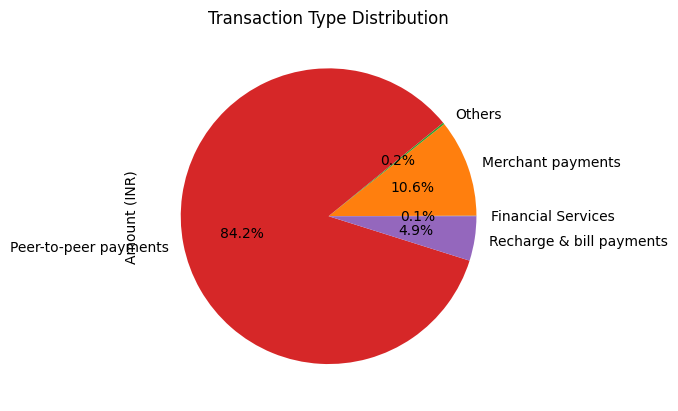

In [10]:
txn_type = txn.groupby('Transaction Type')['Amount (INR)'].sum()

txn_type.plot(kind='pie', autopct='%1.1f%%')
plt.title("Transaction Type Distribution")
plt.show()

## Device Usage Analysis

,Registered Users
Brand,
Xiaomi,615566524
Samsung,480799591
Vivo,411369522
Oppo,283522909
Others,211221642
Realme,134416015
Apple,67132534
Motorola,57086814
OnePlus,44184950


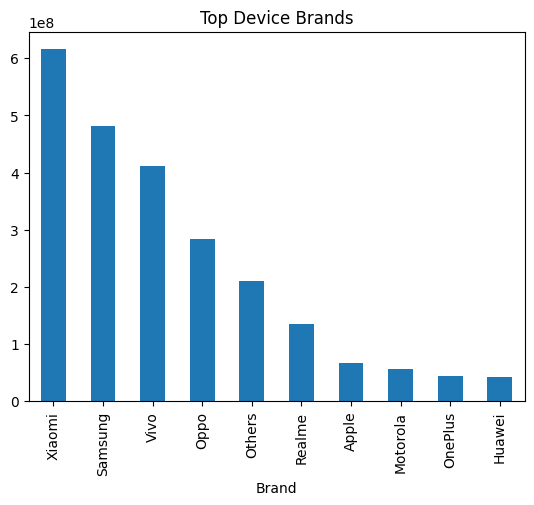

In [11]:
device_usage = device.groupby('Brand')['Registered Users'].sum().sort_values(ascending=False)

display(device_usage.head(10))

device_usage.head(10).plot(kind='bar')
plt.title("Top Device Brands")
plt.show()

## Average Transaction Value (ATV)

In [13]:
state['ATV'] = state['Amount (INR)'] / state['Transactions']

atv_state = state.groupby('State')['ATV'].mean().sort_values(ascending=False)

display(atv_state.head(10))

,ATV
State,
Ladakh,3408.222984
Andaman & Nicobar Islands,3159.266422
Mizoram,2927.517802
Lakshadweep,2776.118701
Arunachal Pradesh,2638.323985
Manipur,2621.225756
Nagaland,2609.942590
Jammu & Kashmir,2508.506029
Chandigarh,2113.797075


## User Engagement Analysis

,Registered Users,App Opens
State,,
Andaman & Nicobar Islands,408396,5554749
Andhra Pradesh,158007957,5352179585
Arunachal Pradesh,1862214,36738885
Assam,26860751,381699610
Bihar,115284760,2043130469


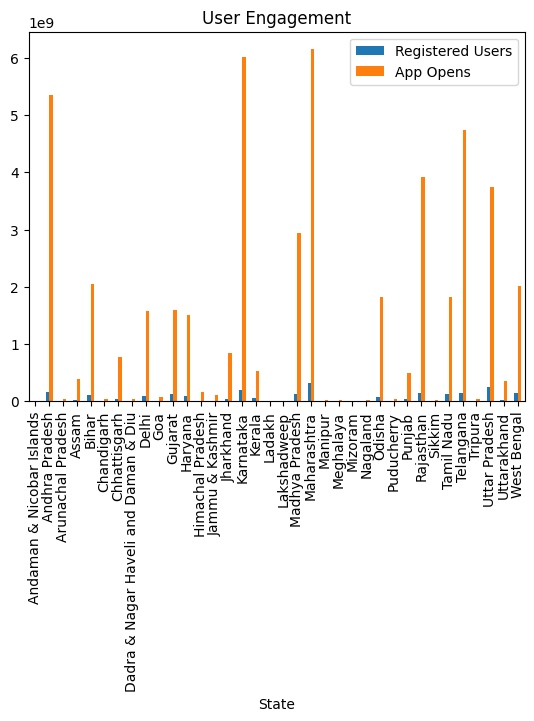

In [14]:
engagement = state.groupby('State')[['Registered Users', 'App Opens']].sum()

display(engagement.head())

engagement.plot(kind='bar')
plt.title("User Engagement")
plt.show()

## District-wise Analysis

In [16]:
district_txn = district.groupby('District')['Amount (INR)'].sum().sort_values(ascending=False)

display(district_txn.head(10))

,Amount (INR)
District,
Bengaluru Urban,2.566575e+12
Hyderabad,1.897550e+12
Pune,1.419771e+12
Jaipur,1.195805e+12
Visakhapatnam,5.836211e+11
Rangareddy,5.752253e+11
Patna,5.115510e+11
Bhopal,4.955893e+11
Medchal Malkajgiri,4.906344e+11


## Merge Demographics + Transactions

In [17]:
merged = pd.merge(district, demo, on=['State', 'District'], how='inner')

display(merged.head())

,State,Year,Quarter,District,Code_x,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Headquarters,Population,Area (sq km),Density,Code_y,Alternate Name
0,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,Port Blair,238142,2672.0,89,AN03,South Andaman
1,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,Port Blair,238142,2672.0,89,AN03,South Andaman
2,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,Port Blair,238142,2672.0,89,AN03,South Andaman
3,Andaman & Nicobar Islands,2018,4,South Andaman,AN03,20136,7.541184e+07,3745.125189,13133,0,Port Blair,238142,2672.0,89,AN03,South Andaman
4,Andaman & Nicobar Islands,2019,1,South Andaman,AN03,25683,8.550197e+07,3329.127142,15961,0,Port Blair,238142,2672.0,89,AN03,South Andaman


## Population vs Transactions

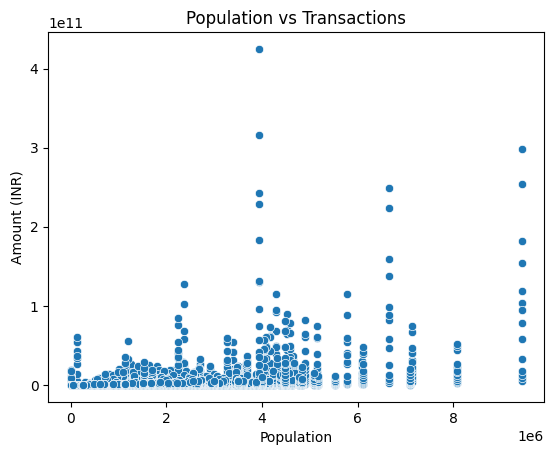

Correlation:
               Population  Amount (INR)
Population      1.000000      0.350666
Amount (INR)    0.350666      1.000000


In [19]:
sns.scatterplot(data=merged, x='Population', y='Amount (INR)')
plt.title("Population vs Transactions")
plt.show()

print("Correlation:\n", merged[['Population', 'Amount (INR)']].corr())

## Density vs Transactions

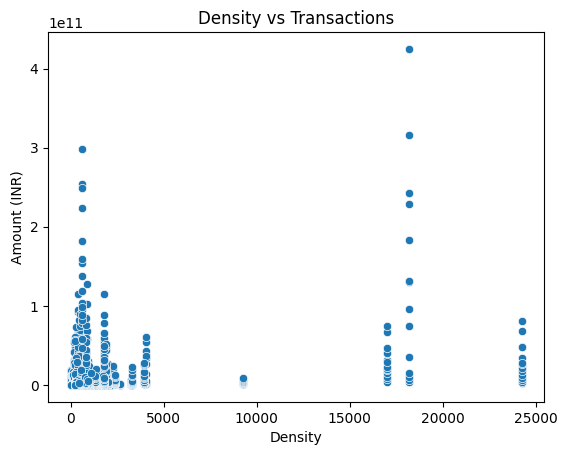

In [21]:
sns.scatterplot(data=merged, x='Density', y='Amount (INR)')
plt.title("Density vs Transactions")
plt.show()

## Data Validation

In [23]:
print("State Total:", state['Amount (INR)'].sum())
print("District Total:", district['Amount (INR)'].sum())

State Total: 35629160262599.375
District Total: 36301604932775.99


## Key Insights

In [24]:
print("Top Performing State:", state_txn.idxmax())
print("Highest ATV State:", atv_state.idxmax())
print("Most Used Device:", device_usage.idxmax())

Top Performing State: Telangana
Highest ATV State: Ladakh
Most Used Device: Xiaomi


## Correlation Heatmap

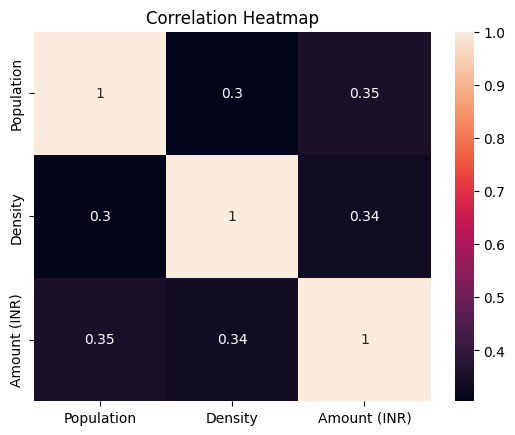

In [26]:
corr = merged[['Population', 'Density', 'Amount (INR)']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()